# Atomistic Simulation of E-beam Milling in h-BN

By Ondrej Dyck

May 21, 2025

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.signal import convolve2d
from scipy.interpolate import RegularGridInterpolator
import matplotlib.patches as patches

## Define h-BN Lattice

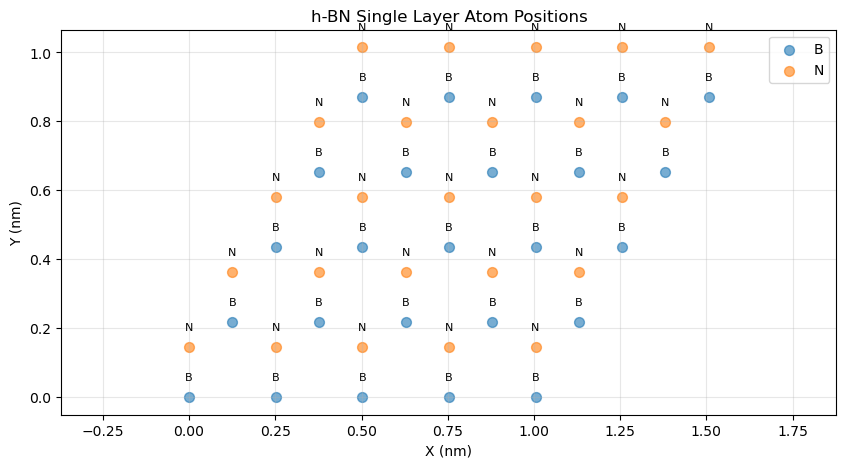

In [33]:

# h-BN lattice parameters
a = 0.145  # B-N bond length
nx, ny = 5, 5  # Tiling factors

# Lattice vectors for hexagonal lattice
a1 = np.array([a * np.sqrt(3), 0])  # (a√3, 0) ≈ (0.433, 0)
a2 = np.array([a * np.sqrt(3) / 2, a * 3 / 2])  # (a√3/2, a*3/2) ≈ (0.2165, 0.375)

# Unit cell basis
basis = [
    np.array([0, 0]),  # Sublattice A (B)
    np.array([0, a])   # Sublattice B (N)
]

# Generate atom positions
atoms = []
for i in range(nx):
    for j in range(ny):
        trans = i * a1 + j * a2
        for k, pos in enumerate(basis):
            x, y = trans + pos
            atom_type = 'B' if k == 0 else 'N'
            atoms.append({'x': x, 'y': y, 'type': atom_type})

# Create Pandas DataFrame
df_atoms = pd.DataFrame(atoms)


# Plot atom positions
plt.figure(figsize=(10, 5))
for atom_type in ['B', 'N']:
    df_subset = df_atoms[df_atoms['type'] == atom_type]
    plt.scatter(df_subset['x'], df_subset['y'], label=atom_type, s=50, alpha=0.6)
for idx, row in df_atoms.iterrows():
    plt.text(row['x'], row['y'] + 0.05, row['type'], fontsize=8, ha='center')
plt.xlabel('X (nm)')
plt.ylabel('Y (nm)')
plt.title('h-BN Single Layer Atom Positions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.savefig('figures/figure6_7/outputs/single_layer_h-BN.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/single_layer_hBN.svg', bbox_inches='tight')
plt.show()

This looks good. We should get a interatomic bond length of 0.145 nm and a unit cell tiling of 0.25 nm.

## Define Bilayer h-BN

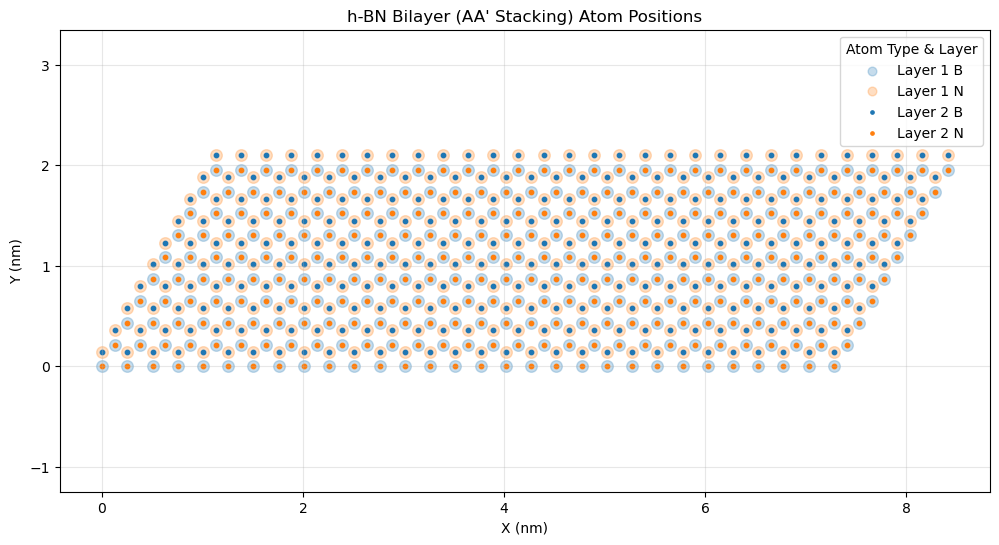

In [34]:
# h-BN lattice parameters
a = 0.145  # B-N bond length (nm)
nx, ny = 30, 10  # Tiling factors
d_interlayer = 0.333  # Interlayer distance (nm)
dwell_time = 36e-6  # Dwell time in seconds (36 microseconds). Will be used later.

# Lattice vectors for hexagonal lattice
a1 = np.array([a * np.sqrt(3), 0])  # (a√3, 0) ≈ (0.251, 0)
a2 = np.array([a * np.sqrt(3) / 2, a * 3 / 2])  # (a√3/2, a*3/2) ≈ (0.1255, 0.2175)

# Unit cell basis
basis = [
    np.array([0, 0]),  # Sublattice A (B in layer 1)
    np.array([0, a])   # Sublattice B (N in layer 1)
]

# Generate single-layer atom positions
atoms = []
for i in range(nx):
    for j in range(ny):
        trans = i * a1 + j * a2
        for k, pos in enumerate(basis):
            x, y = trans + pos
            atom_type = 'B' if k == 0 else 'N'
            atoms.append({'x': x, 'y': y, 'type': atom_type, 'z': 0.0, 'layer': 1})

# Create initial DataFrame for layer 1
df_atoms = pd.DataFrame(atoms)

# Duplicate for layer 2 (AA' stacking)
df_layer2 = df_atoms.copy()
df_layer2['z'] = d_interlayer
df_layer2['layer'] = 2
df_layer2['type'] = df_layer2['type'].map({'B': 'N', 'N': 'B'})

# Combine both layers
df_atoms = pd.concat([df_atoms, df_layer2], ignore_index=True)

# Verify DataFrame
# print("Number of atoms:", len(df_atoms))
# print("DataFrame head:\n", df_atoms.head())
# print("Atom type counts:\n", df_atoms['type'].value_counts())
# print("Layer counts:\n", df_atoms['layer'].value_counts())
# print("Z-coordinate counts:\n", df_atoms['z'].value_counts())

# Plot atom positions
plt.figure(figsize=(12, 6))
colors = {'B': 'C0', 'N': 'C1'}
for atom_type in ['B', 'N']:
    df_subset1 = df_atoms[(df_atoms['layer'] == 1) & (df_atoms['type'] == atom_type)]
    plt.scatter(df_subset1['x'], df_subset1['y'], c=colors[atom_type], s=70, alpha=0.25, 
                label=f'Layer 1 {atom_type}')
for atom_type in ['B', 'N']:
    df_subset2 = df_atoms[(df_atoms['layer'] == 2) & (df_atoms['type'] == atom_type)]
    plt.scatter(df_subset2['x'], df_subset2['y'], c=colors[atom_type], s=10, alpha=1, 
                label=f'Layer 2 {atom_type}')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title='Atom Type & Layer', markerscale=0.75)
plt.xlabel('X (nm)')
plt.ylabel('Y (nm)')
plt.title('h-BN Bilayer (AA\' Stacking) Atom Positions')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.savefig('figures/figure6_7/outputs/bilayer_h-BN.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/bilayer_h-BN.svg', bbox_inches='tight')
plt.show()

## Find Nearest Neighbors
Step 1

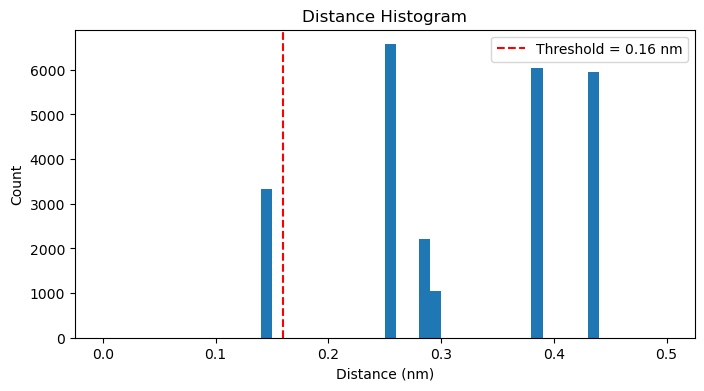

Neighbor count distribution:
 neighbors
1     120
2      36
3    1044
Name: count, dtype: int64


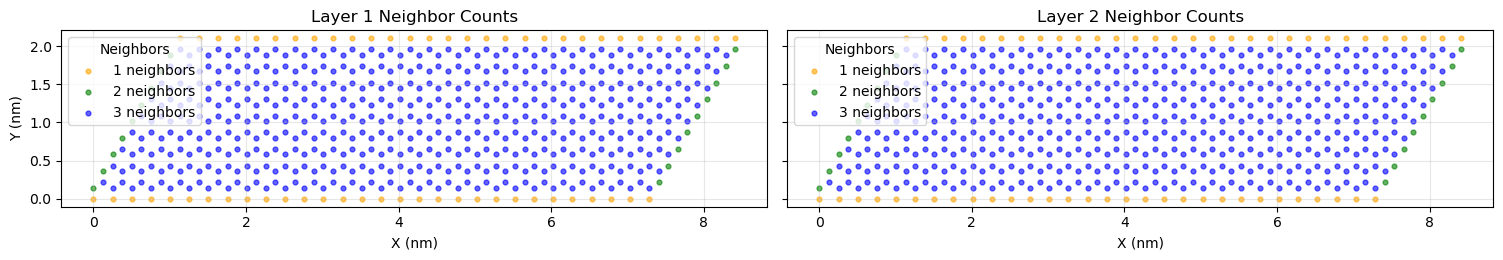

In [35]:
# Neighbor calculation parameters
threshold = 0.16      # Tighter threshold to capture B-N bonds (~0.145 nm)
dwell_time = 36e-6   # Dwell time in seconds (36 microseconds), configurable

# Vectorized neighbor calculation
def count_neighbors(df):
    neighbors = np.zeros(len(df), dtype=int)
    all_distances = []
    for layer in df['layer'].unique():
        mask = df['layer'] == layer
        layer_df = df[mask]
        for idx in layer_df.index:
            distances = np.sqrt((layer_df['x'] - df.loc[idx, 'x'])**2 + (layer_df['y'] - df.loc[idx, 'y'])**2)
            neighbors[idx] = np.sum((distances > 0) & (distances < threshold))
            valid_distances = distances[(distances > 0) & (distances < 0.5)]
            all_distances.extend(valid_distances)
            # Debug: Print distances for first 10 atoms per layer
            #if idx < layer_df.index[0] + 10:
            #    print(f"Atom {idx} (layer {layer}): Min distance = {valid_distances.min() if valid_distances.size > 0 else 'None'} nm, Neighbors = {neighbors[idx]}")
    # Plot distance histogram
    plt.figure(figsize=(8, 4))
    plt.hist(all_distances, bins=50, range=(0, 0.5))
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold} nm')
    plt.xlabel('Distance (nm)')
    plt.ylabel('Count')
    plt.title('Distance Histogram')
    plt.legend()
    plt.show()
    return neighbors

# Apply neighbor calculation if not already done
if 'neighbors' not in df_atoms.columns:
    df_atoms['neighbors'] = count_neighbors(df_atoms)

# Verify neighbor counts
print("Neighbor count distribution:\n", df_atoms['neighbors'].value_counts().sort_index())

# Plot neighbor counts in two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
colors = {0: 'red', 1: 'orange', 2: 'green', 3: 'blue', 4: 'purple', 5: 'cyan', 6: 'magenta', 7: 'yellow', 8: 'black', 9: 'gray'}  # Expanded colors

# Layer 1 plot
for neighbors in sorted(df_atoms['neighbors'].unique()):
    df_subset = df_atoms[(df_atoms['neighbors'] == neighbors) & (df_atoms['layer'] == 1)]
    ax1.scatter(df_subset['x'], df_subset['y'], c=colors.get(neighbors, 'gray'), s=12, alpha=0.6, 
                label=f'{neighbors} neighbors')
ax1.set_xlabel('X (nm)')
ax1.set_ylabel('Y (nm)')
ax1.set_title('Layer 1 Neighbor Counts')
ax1.legend(title='Neighbors')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')


# Layer 2 plot
for neighbors in sorted(df_atoms['neighbors'].unique()):
    df_subset = df_atoms[(df_atoms['neighbors'] == neighbors) & (df_atoms['layer'] == 2)]
    ax2.scatter(df_subset['x'], df_subset['y'], c=colors.get(neighbors, 'gray'), s=12, alpha=0.6, 
                label=f'{neighbors} neighbors')
ax2.set_xlabel('X (nm)')
ax2.set_title('Layer 2 Neighbor Counts')
ax2.legend(title='Neighbors')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')


plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/edge_bulk_analysis.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/edge_bulk_analysis.svg', bbox_inches='tight')
plt.show()

## Assign Ejection Probabilites
Step 2

In [36]:
# Ejection probability parameters
voltage = 100  # kV
k = 1.0  # Scaling factor, tune in Step 7
p_base = {
    'bulk_B': 50e-22 * k,  # 100 kV: 50 barn, nm²
    'bulk_N': 30e-22 * k,  # 30 barn
    'edge_B': 70e-22 * k,  # 70 barn
    'edge_N': 50e-22 * k   # 50 barn
}

# Assign ejection probabilities
df_atoms['is_edge'] = df_atoms['neighbors'] < 3
df_atoms['p_eject'] = df_atoms.apply(
    lambda row: p_base[f"{'edge' if row['is_edge'] else 'bulk'}_{row['type']}"], axis=1
)

# Debug: Print sample p_eject values
print("Sample ejection probabilities:\n", df_atoms[['type', 'layer', 'is_edge', 'neighbors', 'p_eject']].head(10))

# Verify probabilities
print("Ejection probability stats:\n", df_atoms.groupby(['type', 'layer', 'is_edge'])['p_eject'].describe())

Sample ejection probabilities:
   type  layer  is_edge  neighbors       p_eject
0    B      1     True          1  7.000000e-21
1    N      1     True          2  5.000000e-21
2    B      1    False          3  5.000000e-21
3    N      1     True          2  5.000000e-21
4    B      1    False          3  5.000000e-21
5    N      1     True          2  5.000000e-21
6    B      1    False          3  5.000000e-21
7    N      1     True          2  5.000000e-21
8    B      1    False          3  5.000000e-21
9    N      1     True          2  5.000000e-21
Ejection probability stats:
                     count          mean           std           min  \
type layer is_edge                                                    
B    1     False    261.0  5.000000e-21  1.356771e-35  5.000000e-21   
           True      39.0  7.000000e-21  4.572906e-36  7.000000e-21   
     2     False    261.0  5.000000e-21  1.356771e-35  5.000000e-21   
           True      39.0  7.000000e-21  4.572906e-36  7

## Define a Focused Beam Hitting the Sample with Dose Dependence

Step 3

Dose stats:
        count        mean          std  min            25%           50%  \
layer                                                                     
1      600.0  251.779478  3040.184409  0.0  1.663238e-177  1.139017e-81   
2      600.0  251.779478  3040.184409  0.0  1.663238e-177  1.139017e-81   

                75%           max  
layer                              
1      9.974300e-25  62593.422783  
2      9.974300e-25  62593.422783  


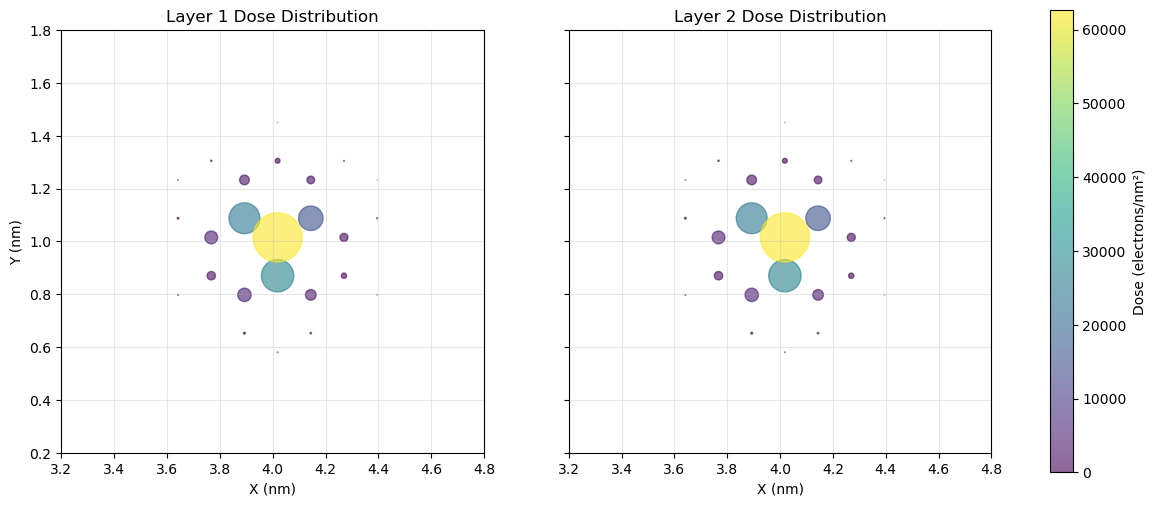

In [37]:
# Gaussian beam parameters
I = 18e-12  # Beam current (A), 18 pA
t = 36e-6   # Dwell time (s), 36 µs
e = 1.602e-19  # Electron charge (C)
phi_0 = (I * t) / e  # Total electrons ≈ 4.045e6
sigma = 0.1  # Beam width (nm)
x_0, y_0 = 4, 1  # Beam center (nm)

# Calculate dose
df_atoms['dose'] = (phi_0 / (2 * np.pi * sigma**2)) * np.exp(
    -((df_atoms['x'] - x_0)**2 + (df_atoms['y'] - y_0)**2) / (2 * sigma**2)
)

# Clip small doses to avoid plotting artifacts
dose_threshold = 1  # electrons/nm²
df_atoms['dose_plot'] = np.where(df_atoms['dose'] > dose_threshold, df_atoms['dose'], 0)

# Verify dose
print("Dose stats:\n", df_atoms.groupby('layer')['dose'].describe())

# Plot dose distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for layer in [1, 2]:
    df_subset = df_atoms[df_atoms['layer'] == layer]
    ax = ax1 if layer == 1 else ax2
    scatter = ax.scatter(df_subset['x'], df_subset['y'], 
                        s=df_subset['dose_plot'] / 50, 
                        c=df_subset['dose'], cmap='viridis', alpha=0.6)
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)' if layer == 1 else '')
    ax.set_title(f'Layer {layer} Dose Distribution')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    n=8
    ax.set_xlim(x_0-n*sigma,x_0+n*sigma)
    ax.set_ylim(y_0-n*sigma,y_0+n*sigma)
fig.colorbar(scatter, ax=[ax1, ax2], label='Dose (electrons/nm²)')
plt.savefig('figures/figure6_7/outputs/beam_on_sample.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/beam_on_sample.svg', bbox_inches='tight')
plt.show()

## Calculate Ejections for One Step

Step 4

P_scaled stats:
             count      mean       std  min            25%           50%  \
layer type                                                                
1     B     300.0  0.005912  0.057474  0.0  4.158095e-182  3.401976e-87   
      N     300.0  0.004006  0.054561  0.0  2.085874e-181  3.586181e-86   
2     B     300.0  0.004794  0.058700  0.0  3.476457e-181  5.400970e-86   
      N     300.0  0.003547  0.034484  0.0  2.494857e-182  2.088631e-87   

                     75%       max  
layer type                          
1     B     1.897299e-29  0.679791  
      N     1.562743e-29  0.938901  
2     B     2.604572e-29  1.000000  
      N     1.138379e-29  0.407875  
Ejection stats:
 ejected       0  1
layer type        
1     B     298  2
      N     299  1
2     B     299  1
      N     299  1


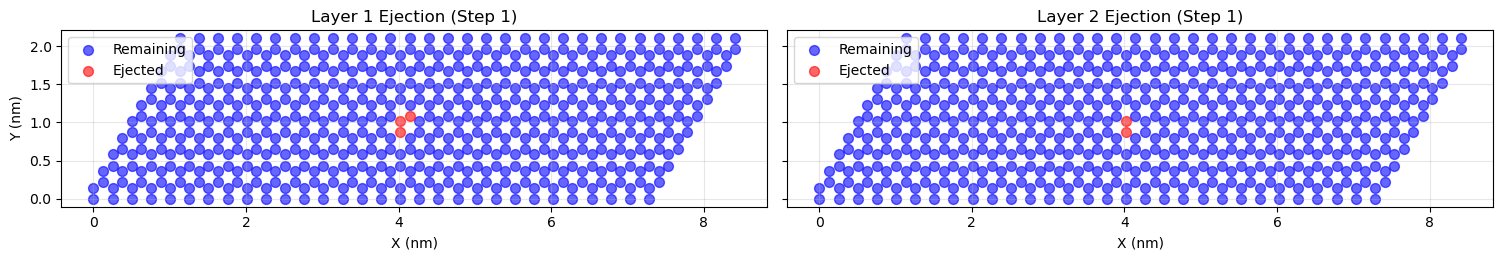

In [38]:
# Ejection parameters
k_eject = 5e15  # Scaling factor to tune ejection rates (adjust as needed)
np.random.seed(42)  # For reproducibility

# Calculate scaled ejection probability: P = min(p_eject * dose * k_eject, 1)
df_atoms['P_scaled'] = np.minimum(df_atoms['p_eject'] * df_atoms['dose'] * k_eject, 1.0)

# Simulate ejection: eject if P_scaled > random[0, 1]
df_atoms['ejected'] = (df_atoms['P_scaled'] > np.random.random(len(df_atoms))).astype(int)

# Debug: Print P_scaled stats
print("P_scaled stats:\n", df_atoms.groupby(['layer', 'type'])['P_scaled'].describe())

# Verify ejections
print("Ejection stats:\n", df_atoms.groupby(['layer', 'type'])['ejected'].value_counts().unstack(fill_value=0))

# Plot remaining vs. ejected atoms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for layer in [1, 2]:
    ax = ax1 if layer == 1 else ax2
    df_remaining = df_atoms[(df_atoms['layer'] == layer) & (df_atoms['ejected'] == 0)]
    df_ejected = df_atoms[(df_atoms['layer'] == layer) & (df_atoms['ejected'] == 1)]
    ax.scatter(df_remaining['x'], df_remaining['y'], c='blue', s=50, alpha=0.6, label='Remaining')
    ax.scatter(df_ejected['x'], df_ejected['y'], c='red', s=50, alpha=0.6, label='Ejected')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)' if layer == 1 else '')
    ax.set_title(f'Layer {layer} Ejection (Step 1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/one_step_ejection.png', bbox_inches='tight', dpi=200)
plt.show()

## Calculate Ejections for Multiple Steps

Step 5

In [39]:

# Vectorized neighbor calculation
def count_neighbors(df):
    neighbors = np.zeros(len(df), dtype=int)
    for layer in df['layer'].unique():
        mask = (df['layer'] == layer) & (df['ejected'] == 0)
        layer_df = df[mask].copy()  # Work with a copy of unejected atoms
        for idx in df.index:
            if mask[idx]:
                distances = np.sqrt((layer_df['x'] - df.loc[idx, 'x'])**2 + (layer_df['y'] - df.loc[idx, 'y'])**2)
                neighbors[idx] = np.sum((distances > 0) & (distances < threshold))
    return neighbors

# Function to extract DataFrame from data cube
def get_step_df(data_cube, step):
    df = pd.DataFrame(data_cube[step], columns=columns)
    df['type'] = df['type'].map({0: 'B', 1: 'N'})
    df['layer'] = df['layer'].astype(int)
    df['neighbors'] = df['neighbors'].astype(int)
    df['ejected'] = df['ejected'].astype(int)
    df['is_edge'] = df['is_edge'].astype(bool)
    return df

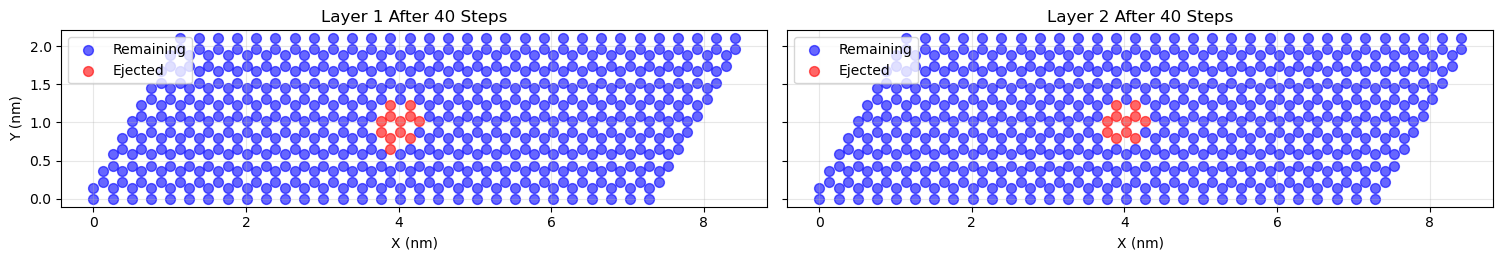

In [40]:
# Parameters
n_steps = 40

np.random.seed(42)  # For reproducibility

# Reset ejected status and neighbors at the start
df_atoms['ejected'] = 0
df_atoms['neighbors'] = 0  # Reset neighbors for all atoms


# Recalculate neighbors for initial state
df_atoms['neighbors'] = count_neighbors(df_atoms)
df_atoms['is_edge'] = df_atoms['neighbors'] < 3

# Initialize data cube to store state at each step
columns = ['x', 'y', 'z', 'type', 'layer', 'neighbors', 'p_eject', 'dose', 'P_scaled', 'ejected', 'is_edge']
n_atoms = len(df_atoms)
data_cube = np.zeros((n_steps + 1, n_atoms, len(columns)))  # +1 for initial state
df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})  # Map to numeric for storage
data_cube[0, :, :] = df_atoms[columns].values  # Store initial state
df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})  # Revert to string

# Debug initial state
#print(f"Initial - Ejected: {sum(df_atoms['ejected'] == 1)}, Edge atoms: {sum(df_atoms['is_edge'])}")

# Simulate multiple milling steps
for step in range(n_steps):
    # Update neighbors for non-ejected atoms (pre-ejection)
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    
    # Update is_edge and p_eject based on new neighbors
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3
    df_atoms.loc[df_atoms['ejected'] == 0, 'p_eject'] = df_atoms[df_atoms['ejected'] == 0].apply(
        lambda row: p_base[f"{'edge' if row['is_edge'] else 'bulk'}_{row['type']}"], axis=1
    )
    
    # Scale probabilities and eject (store pre-ejection state for debug)
    pre_ejection_neighbors = df_atoms['neighbors'].copy()
    df_atoms['P_scaled'] = np.minimum(df_atoms['p_eject'] * df_atoms['dose'] * k_eject, 1.0)
    df_atoms.loc[df_atoms['ejected'] == 0, 'ejected'] = (
        df_atoms.loc[df_atoms['ejected'] == 0, 'P_scaled'] > np.random.random(sum(df_atoms['ejected'] == 0))
    ).astype(int)
    
    # Recalculate neighbors post-ejection
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3  # Update is_edge after recalculation
    
    # Store state in data_cube after ejection and neighbor update
    df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})
    data_cube[step + 1, :, :] = df_atoms[columns].values
    df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})
    
    # Debug each step
    ejected_count = sum(df_atoms['ejected'] == 1)
    edge_count = sum(df_atoms['is_edge'])
    #print(f"Step {step + 1} - Ejected: {ejected_count}, Edge atoms: {edge_count}, "
    #      f"Sample neighbors: {df_atoms['neighbors'].head().tolist()}")
    if step == 0:  # Extra debug for step 1
        ejected_indices = df_atoms[df_atoms['ejected'] == 1].index
        # Compute pairwise distances between all atoms and ejected atoms
        x_ejected = df_atoms.loc[ejected_indices, 'x'].values
        y_ejected = df_atoms.loc[ejected_indices, 'y'].values
        x_all = df_atoms['x'].values
        y_all = df_atoms['y'].values
        # Broadcasting: (n_atoms, 1) - (n_ejected,) to get (n_atoms, n_ejected)
        dx = x_all[:, np.newaxis] - x_ejected  # Shape (1200, 5)
        dy = y_all[:, np.newaxis] - y_ejected  # Shape (1200, 5)
        distances = np.sqrt(dx**2 + dy**2)  # Shape (1200, 5)
        min_distances = np.min(distances, axis=1)  # Shape (1200,)
        adjacent_mask = (min_distances < threshold * 2) & (df_atoms['ejected'] == 0)
        #print(f"Step 1 - Pre-ejection neighbors of ejected: {pre_ejection_neighbors[df_atoms['ejected'] == 1].value_counts().to_dict()}")
        #print(f"Step 1 - Post-ejection neighbors of ejected: {df_atoms.loc[df_atoms['ejected'] == 1, 'neighbors'].value_counts().to_dict()}")
        #print(f"Step 1 - Neighbor counts of adjacent unejected: {df_atoms.loc[adjacent_mask, 'neighbors'].value_counts().to_dict()}")

# Debug: Print final stats
#print("Final ejection stats:\n", df_atoms.groupby(['layer', 'type'])['ejected'].value_counts().unstack(fill_value=0))

# Original plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for layer in [1, 2]:
    ax = ax1 if layer == 1 else ax2
    df_remaining = df_atoms[(df_atoms['layer'] == layer) & (df_atoms['ejected'] == 0)]
    df_ejected = df_atoms[(df_atoms['layer'] == layer) & (df_atoms['ejected'] == 1)]
    ax.scatter(df_remaining['x'], df_remaining['y'], c='blue', s=50, alpha=0.6, label='Remaining')
    ax.scatter(df_ejected['x'], df_ejected['y'], c='red', s=50, alpha=0.6, label='Ejected')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)' if layer == 1 else '')
    ax.set_title(f'Layer {layer} After {n_steps} Steps')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/stationary_beam_40_steps.png', bbox_inches='tight', dpi=200)
plt.show()

## Check Ejection Steps

We want to double check that our classification scheme is catching the edge atoms when they appear around the hole.

We can use the variable `chosen_step` to plot the steps from the previous cell and check. Edge atoms should be red, bulk atoms should be blue, and ejected atoms should be gray.

Step 20 - Ejected atoms: 20


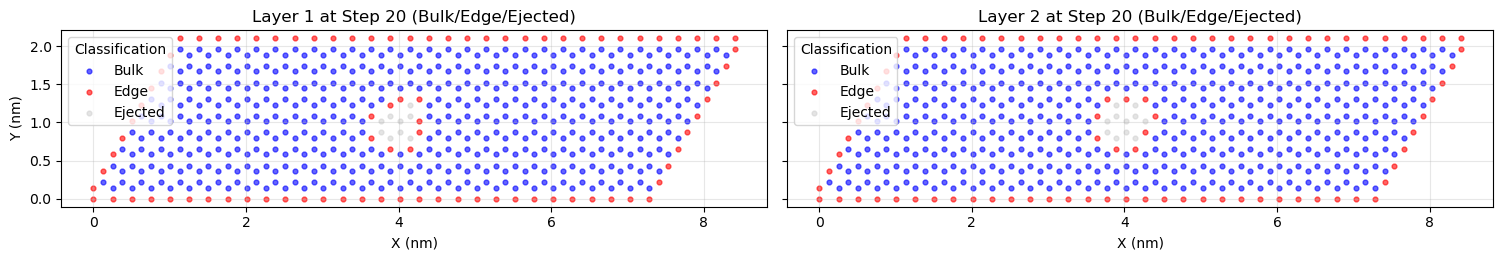

In [41]:



# User-specified step to visualize
chosen_step = 20  # Example: Must be <= n_steps (e.g., 40)

# Verify step is valid and extract data
if chosen_step < 0 or chosen_step > n_steps:
    raise ValueError(f"Chosen step {chosen_step} is out of range. Must be between 0 and {n_steps}.")
df_step = get_step_df(data_cube, chosen_step)

# Debug: Print ejected count to verify step data
print(f"Step {chosen_step} - Ejected atoms: {sum(df_step['ejected'] == 1)}")

# Plot state with bulk/edge/ejected color-coding
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
colors = {'bulk': 'blue', 'edge': 'red', 'ejected': 'lightgray'}

# Layer 1 plot
for ejected in [0, 1]:
    df_ejected = df_step[(df_step['ejected'] == ejected) & (df_step['layer'] == 1)]
    if ejected == 1:
        ax1.scatter(df_ejected['x'], df_ejected['y'], c=colors['ejected'], s=12, alpha=0.6, 
                    label='Ejected')
    else:
        for is_edge in [False, True]:
            df_subset = df_ejected[(df_ejected['is_edge'] == is_edge)]
            label = 'Bulk' if not is_edge else 'Edge'
            ax1.scatter(df_subset['x'], df_subset['y'], c=colors[label.lower()], s=12, alpha=0.6, 
                        label=label)
ax1.set_xlabel('X (nm)')
ax1.set_ylabel('Y (nm)')
ax1.set_title(f'Layer 1 at Step {chosen_step} (Bulk/Edge/Ejected)')
ax1.legend(title='Classification')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Layer 2 plot
for ejected in [0, 1]:
    df_ejected = df_step[(df_step['ejected'] == ejected) & (df_step['layer'] == 2)]
    if ejected == 1:
        ax2.scatter(df_ejected['x'], df_ejected['y'], c=colors['ejected'], s=12, alpha=0.6, 
                    label='Ejected')
    else:
        for is_edge in [False, True]:
            df_subset = df_ejected[(df_ejected['is_edge'] == is_edge)]
            label = 'Bulk' if not is_edge else 'Edge'
            ax2.scatter(df_subset['x'], df_subset['y'], c=colors[label.lower()], s=12, alpha=0.6, 
                        label=label)
ax2.set_xlabel('X (nm)')
ax2.set_title(f'Layer 2 at Step {chosen_step} (Bulk/Edge/Ejected)')
ax2.legend(title='Classification')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/ejection_edge.png', bbox_inches='tight', dpi=200)
plt.show()

## Simulate a Line Cut with a Parallel Milling Pattern

Step 6

x_max (atoms): 8.413436797765822
y_max (atoms): 2.1024999999999996
x_grid max: 8.450000000000001
y_grid max: 2.15


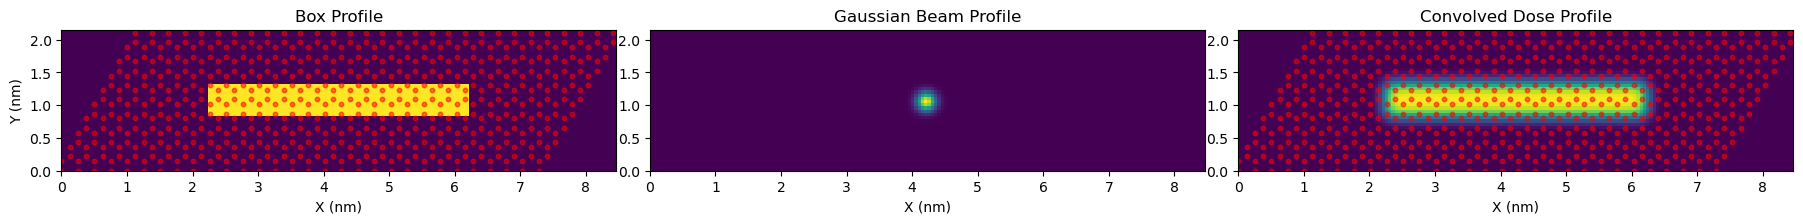

Completed in 12 steps, cumulative dose: 2840934664.89
Snapshot steps: [0, 2, 12]
Ejections per step: [37, 28, 25, 14, 12, 3, 5, 2, 1, 0, 0, 1]


/tmp/ipykernel_20361/139481078.py:175: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_20361/139481078.py:175: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


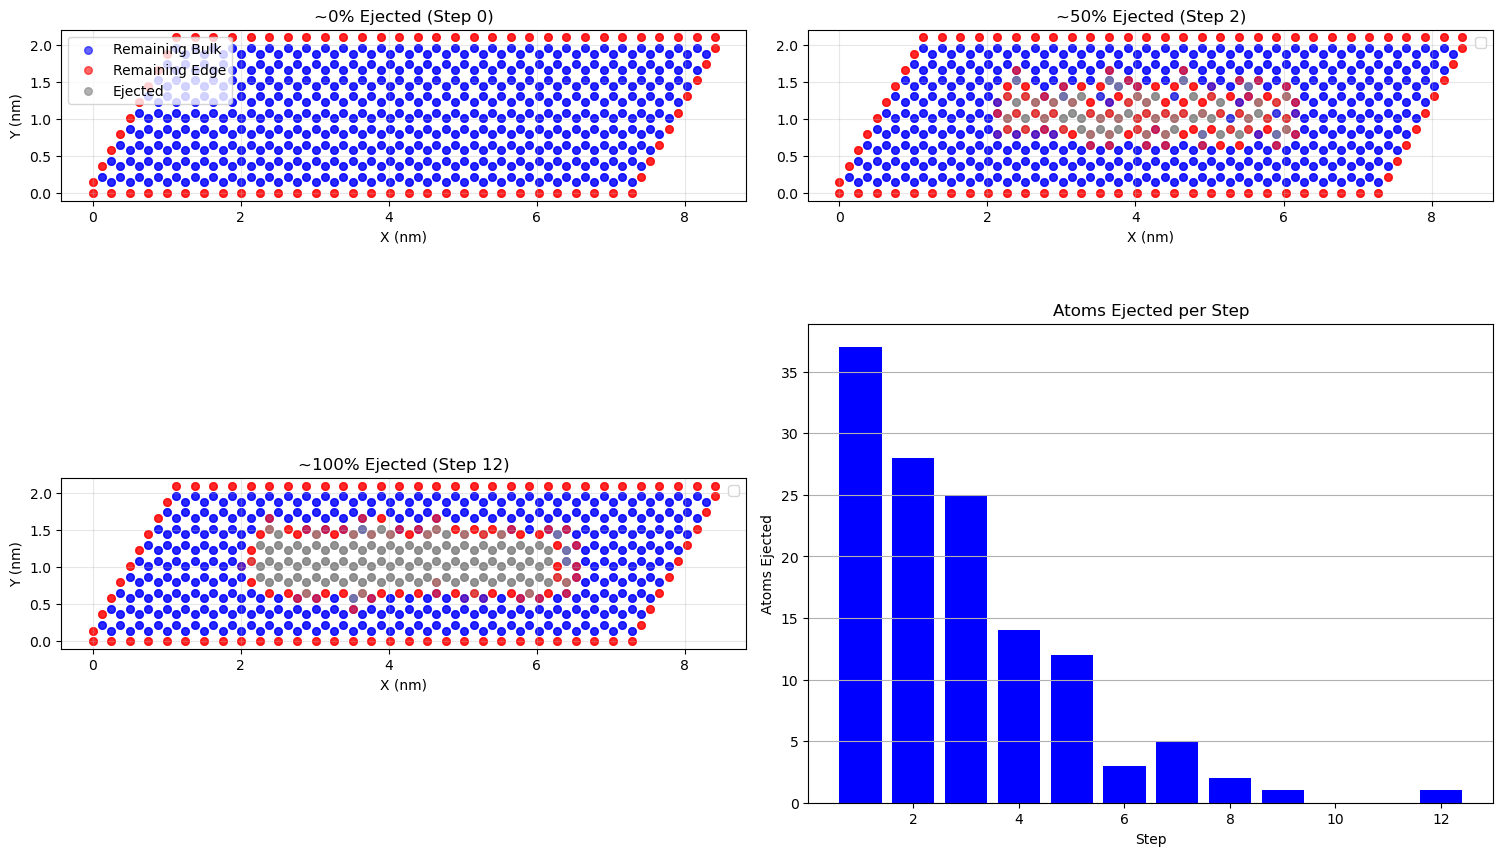

In [42]:
# Reset ejected status and dose
df_atoms['ejected'] = 0
df_atoms['dose'] = 0

k_eject = 5e13  # Scaling factor to tune ejection rates (adjust as needed)

# Skinny box parameters
box_width = 4  # nm (adjusted to fit lattice)
box_height = 0.5  # nm
x_max = (nx - 1) * a1[0] + (ny - 1) * a2[0] 
y_max = (ny - 1) * a2[1] + a
box_center_x = x_max / 2
box_center_y = y_max / 2
x_bounds = (box_center_x - box_width / 2, box_center_x + box_width / 2)
y_bounds = (box_center_y - box_height / 2, box_center_y + box_height / 2)

# Time out
max_steps = 1000

# Skinny box bounds
box_mask = (df_atoms['x'].between(*x_bounds) & df_atoms['y'].between(*y_bounds))
box_atoms = sum(box_mask)

# Convolution grid setup
grid_step = 0.05  # Grid resolution (nm)
# Use actual atom positions to define grid ranges
x_max_atoms = df_atoms['x'].max()
y_max_atoms = df_atoms['y'].max()
x_grid = np.arange(0, x_max_atoms + grid_step, grid_step)
y_grid = np.arange(0, y_max_atoms + grid_step, grid_step)
X, Y = np.meshgrid(x_grid, y_grid)

# Box profile
box_profile = np.zeros_like(X)
box_profile[(X >= x_bounds[0]) & (X <= x_bounds[1]) & (Y >= y_bounds[0]) & (Y <= y_bounds[1])] = 1.0

# Gaussian beam profile
gaussian_profile = (phi_0 / (2 * np.pi * sigma**2)) * np.exp(
    -((X - box_center_x)**2 + (Y - box_center_y)**2) / (2 * sigma**2)
)

# Convolve box with Gaussian
dose_profile_skinny = convolve2d(box_profile, gaussian_profile, mode='same')

# Interpolate dose at atom positions
interpolator = RegularGridInterpolator((y_grid, x_grid), dose_profile_skinny, method='linear', bounds_error=False, fill_value=0)
df_atoms['step_dose'] = interpolator((df_atoms['y'], df_atoms['x']))

# Debug: Verify grid and atom positions
print(f"x_max (atoms): {x_max_atoms}")
print(f"y_max (atoms): {y_max_atoms}")
print(f"x_grid max: {x_grid[-1]}")
print(f"y_grid max: {y_grid[-1]}")

# Plot profiles with atom overlay, using actual atom ranges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(box_profile, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
axes[0].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[0].set_title('Box Profile')
axes[0].set_xlabel('X (nm)')
axes[0].set_ylabel('Y (nm)')

axes[1].imshow(gaussian_profile, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
#axes[1].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[1].set_title('Gaussian Beam Profile')
axes[1].set_xlabel('X (nm)')

axes[2].imshow(dose_profile_skinny, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
axes[2].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[2].set_title('Convolved Dose Profile')
axes[2].set_xlabel('X (nm)')

plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/parallel_mill_strategy.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/parallel_mill_strategy.svg', bbox_inches='tight')
plt.show()

# Initialize data cube: (steps, atoms, columns)
n_atoms = len(df_atoms)
columns = ['x', 'y', 'z', 'type', 'layer', 'neighbors', 'p_eject', 'dose', 'P_scaled', 'ejected', 'is_edge']
df_atoms['neighbors'] = 0  # Reset neighbors for all atoms
df_atoms['neighbors'] = count_neighbors(df_atoms)
df_atoms['is_edge'] = df_atoms['neighbors'] < 3  # Ensure is_edge is initialized
df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})
data_cube_skinny = np.zeros((max_steps, n_atoms, len(columns)))
data_cube_skinny[0, :, :] = df_atoms[columns].values
df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})

# Track progress
cumulative_dose = 0
steps = 0
ejected_in_box = 0
prev_ejected_in_box = 0
snapshot_steps = [0]
snapshot_fractions = [0.0]
captured_50 = False
ejections_per_step = []

# Milling loop
while ejected_in_box < box_atoms and steps < max_steps - 1:
    steps += 1
    
    # Update neighbors (pre-ejection)
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    
    # Update p_eject
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3
    df_atoms.loc[df_atoms['ejected'] == 0, 'p_eject'] = df_atoms[df_atoms['ejected'] == 0].apply(
        lambda row: p_base[f"{'edge' if row['is_edge'] else 'bulk'}_{row['type']}"], axis=1
    )
    
    # Apply convolved dose
    df_atoms['step_dose'] = interpolator((df_atoms['y'], df_atoms['x']))
    df_atoms['dose'] += df_atoms['step_dose']
    df_atoms['P_scaled'] = np.minimum(df_atoms['p_eject'] * df_atoms['step_dose'] * k_eject, 1.0)
    df_atoms.loc[df_atoms['ejected'] == 0, 'ejected'] = (
        df_atoms.loc[df_atoms['ejected'] == 0, 'P_scaled'] > np.random.random(sum(df_atoms['ejected'] == 0))
    ).astype(int)
    
    # Recalculate neighbors post-ejection
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3  # Update is_edge after recalculation
    
    # Update dose and ejection count
    cumulative_dose += df_atoms['step_dose'].sum()
    ejected_in_box = sum(df_atoms[box_mask]['ejected'])
    ejections_per_step.append(ejected_in_box - prev_ejected_in_box)
    prev_ejected_in_box = ejected_in_box
    
    # Store step data
    df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})
    data_cube_skinny[steps, :, :] = df_atoms[columns].values
    df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})
    
    # Store snapshot at ~50%
    fraction = ejected_in_box / box_atoms
    if not captured_50 and fraction >= 0.5:
        snapshot_steps.append(steps)
        snapshot_fractions.append(0.5)
        captured_50 = True

# Store final state
snapshot_steps.append(steps)
snapshot_fractions.append(fraction)
data_cube_skinny = data_cube_skinny[:steps + 1]
print(f"Completed in {steps} steps, cumulative dose: {cumulative_dose:.2f}")
print(f"Snapshot steps: {snapshot_steps}")
print(f"Ejections per step: {ejections_per_step}")

# Save for Step 8
dose_skinny_total = cumulative_dose
df_skinny = df_atoms.copy()

# Plot snapshots with edge atoms in red
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, (frac, step) in enumerate(zip(snapshot_fractions, snapshot_steps)):
    df_snap = get_step_df(data_cube_skinny, step)
    ax = axes[i]
    for layer in [1, 2]:
        # Remaining non-edge atoms (blue)
        df_remaining_non_edge = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 0) & (~df_snap['is_edge'])]
        ax.scatter(df_remaining_non_edge['x'], df_remaining_non_edge['y'], c='blue', s=30, alpha=0.6, label='Remaining Bulk' if layer == 1 and i == 0 else "")
        # Remaining edge atoms (red)
        df_remaining_edge = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 0) & (df_snap['is_edge'])]
        ax.scatter(df_remaining_edge['x'], df_remaining_edge['y'], c='red', s=30, alpha=0.6, label='Remaining Edge' if layer == 1 and i == 0 else "")
        # Ejected atoms (gray)
        df_ejected = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 1)]
        ax.scatter(df_ejected['x'], df_ejected['y'], c='gray', s=30, alpha=0.6, label='Ejected' if layer == 1 and i == 0 else "")
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)' if i % 2 == 0 else '')
    ax.set_title(f'~{int(frac*100)}% Ejected (Step {step})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Bar chart of ejections per step
axes[-1].bar(range(1, steps + 1), ejections_per_step, color='blue')
axes[-1].set_xlabel('Step')
axes[-1].set_ylabel('Atoms Ejected')
axes[-1].set_title('Atoms Ejected per Step')
axes[-1].grid(True, axis='y')
plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/parellel_mill_result.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/parellel_mill_result.svg', bbox_inches='tight')
plt.show()

## Simulate a Line Cut with a Sequential Mill Pattern

Step 7

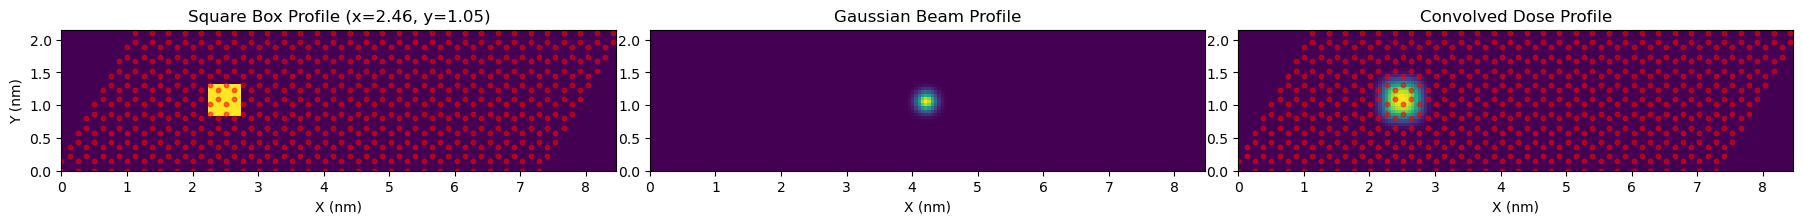

Step 1, Position 0 (2.46, 1.05), Target Atoms: 13, Ejected in Box: 3, Total Ejected: 4, New Ejections: 4, New Ejections in Box: 3, New Ejections Outside Box: 1
Step 2, Position 0 (2.46, 1.05), Target Atoms: 9, Ejected in Box: 7, Total Ejected: 9, New Ejections: 5, New Ejections in Box: 4, New Ejections Outside Box: 1
Step 3, Position 0 (2.46, 1.05), Target Atoms: 6, Ejected in Box: 10, Total Ejected: 12, New Ejections: 3, New Ejections in Box: 3, New Ejections Outside Box: 0
Step 4, Position 0 (2.46, 1.05), Target Atoms: 4, Ejected in Box: 12, Total Ejected: 14, New Ejections: 2, New Ejections in Box: 2, New Ejections Outside Box: 0
Step 5, Position 0 (2.46, 1.05), Target Atoms: 1, Ejected in Box: 15, Total Ejected: 17, New Ejections: 3, New Ejections in Box: 3, New Ejections Outside Box: 0
Step 6, Position 1 (2.96, 1.05), Target Atoms: 13, Ejected in Box: 16, Total Ejected: 19, New Ejections: 2, New Ejections in Box: 1, New Ejections Outside Box: 1
Step 7, Position 1 (2.96, 1.05), Tar

/tmp/ipykernel_20361/3346617011.py:232: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_20361/3346617011.py:232: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


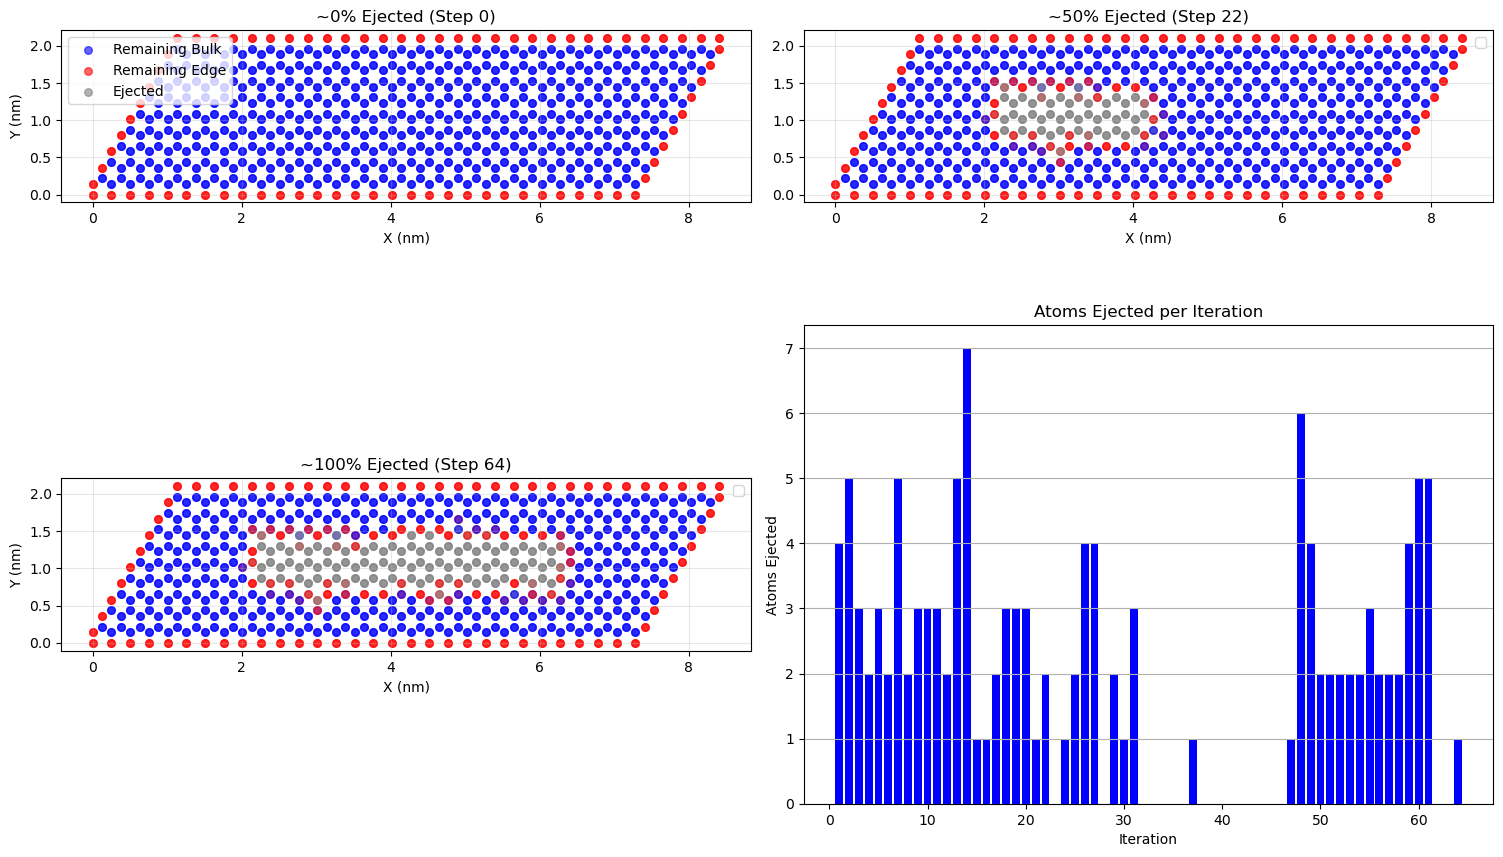

In [43]:
# Reset ejected status
df_atoms['ejected'] = 0
df_atoms['dose'] = 0  # Reset dose

# Target region (same as skinny box in Step 6)
x_bounds_target = x_bounds  # Use Step 6's x_bounds
y_bounds_target = y_bounds  # Use Step 6's y_bounds

# Square box parameters
box_side = box_height  # Square box side length (nm, matches box_height)
step_size = 0.5  # Step size for moving box (nm)
x_positions = np.arange(x_bounds_target[0] + box_side / 2, x_bounds_target[1] - box_side / 2 + step_size, step_size)
y_positions = np.arange(y_bounds_target[0] + box_side / 2, y_bounds_target[1] - box_side / 2 + step_size, step_size)
box_positions = [(x, y) for x in x_positions for y in y_positions]

# Convolution grid setup
x_max_atoms = df_atoms['x'].max()
y_max_atoms = df_atoms['y'].max()
x_grid = np.arange(0, x_max_atoms + grid_step, grid_step)
y_grid = np.arange(0, y_max_atoms + grid_step, grid_step)
X, Y = np.meshgrid(x_grid, y_grid)

# Initialize data cube: (steps, atoms, columns)
n_atoms = len(df_atoms)
columns = ['x', 'y', 'z', 'type', 'layer', 'neighbors', 'p_eject', 'dose', 'P_scaled', 'ejected', 'is_edge']
df_atoms['neighbors'] = 0  # Reset neighbors for all atoms
df_atoms['neighbors'] = count_neighbors(df_atoms)
df_atoms['is_edge'] = df_atoms['neighbors'] < 3  # Ensure is_edge is initialized
df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})
data_cube_square = np.zeros((max_steps, n_atoms, len(columns)))
data_cube_square[0, :, :] = df_atoms[columns].values
df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})

# Track progress
cumulative_dose = 0
steps = 0
snapshot_steps = [0]  # Steps for 0%, 50%, 100%
snapshot_fractions = [0.0]
captured_50 = False
ejections_per_step = []
prev_total_ejected = 0  # Track previous total ejections

# Total target atoms for loop exit and snapshots
total_target_mask = (df_atoms['x'].between(*x_bounds_target) & df_atoms['y'].between(*y_bounds_target))
total_target_atoms = sum(total_target_mask)
total_ejected = 0

# Plot sample dose profile (first position)
box_x, box_y = box_positions[0]
box_profile = np.zeros_like(X)
box_profile[
    (X >= box_x - box_side / 2) & (X <= box_x + box_side / 2) &
    (Y >= box_y - box_side / 2) & (Y <= box_y + box_side / 2)
] = 1.0

dose_profile_square = convolve2d(box_profile, gaussian_profile, mode='same')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(box_profile, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
axes[0].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[0].set_title(f'Square Box Profile (x={box_x:.2f}, y={box_y:.2f})')
axes[0].set_xlabel('X (nm)')
axes[0].set_ylabel('Y (nm)')

axes[1].imshow(gaussian_profile, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
#axes[1].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[1].set_title('Gaussian Beam Profile')
axes[1].set_xlabel('X (nm)')

axes[2].imshow(dose_profile_square, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
axes[2].scatter(df_atoms['x'], df_atoms['y'], c='red', s=10, alpha=0.3)
axes[2].set_title('Convolved Dose Profile')
axes[2].set_xlabel('X (nm)')

plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/sequential_mill_dose_profile.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/sequential_mill_dose_profile.svg', bbox_inches='tight')
plt.show()

# Milling loop
position_idx = 0
dose_profile = []
dose_profile.append(dose_profile_square)
box_ejected = {i: 0 for i in range(len(box_positions))}  # Track ejections per box position
no_ejection_count = 0  # Count steps with no new ejections

while total_ejected < total_target_atoms and steps < max_steps - 1:
    steps += 1
    
    # Get current box position
    box_x, box_y = box_positions[position_idx]
    
    # Dynamic box mask
    box_mask = (
        (df_atoms['x'].between(box_x - box_side / 2, box_x + box_side / 2)) &
        (df_atoms['y'].between(box_y - box_side / 2, box_y + box_side / 2))
    )
    target_atoms = sum(box_mask & (df_atoms['ejected'] == 0))  # Unejected atoms in current box
    
    # Define target atoms for this position (before ejection)
    current_target_mask = box_mask & (df_atoms['ejected'] == 0)
    initial_target_atoms = df_atoms.index[current_target_mask].tolist()
    
    # Create box and Gaussian profiles
    box_profile = np.zeros_like(X)
    box_profile[
        (X >= box_x - box_side / 2) & (X <= box_x + box_side / 2) &
        (Y >= box_y - box_side / 2) & (Y <= box_y + box_side / 2)
    ] = 1.0
    
    # Convolve
    dose_profile_square = convolve2d(box_profile, gaussian_profile, mode='same')
    dose_profile.append(dose_profile_square)
    
    # Interpolate dose
    interpolator = RegularGridInterpolator((y_grid, x_grid), dose_profile_square, method='linear', bounds_error=False, fill_value=0)
    df_atoms['step_dose'] = interpolator((df_atoms['y'], df_atoms['x']))
    
    # Update neighbors (pre-ejection)
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    
    # Update p_eject
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3
    df_atoms.loc[df_atoms['ejected'] == 0, 'p_eject'] = df_atoms[df_atoms['ejected'] == 0].apply(
        lambda row: p_base[f"{'edge' if row['is_edge'] else 'bulk'}_{row['type']}"], axis=1
    )
    
    # Store pre-ejection state to detect new ejections
    pre_ejection = df_atoms['ejected'].copy()
    
    # Apply dose and eject
    df_atoms['dose'] += df_atoms['step_dose']
    df_atoms['P_scaled'] = np.minimum(df_atoms['p_eject'] * df_atoms['step_dose'] * k_eject, 1.0)
    df_atoms.loc[df_atoms['ejected'] == 0, 'ejected'] = (
        df_atoms.loc[df_atoms['ejected'] == 0, 'P_scaled'] > np.random.random(sum(df_atoms['ejected'] == 0))
    ).astype(int)
    
    # Detect new ejections from the current position's target atoms
    new_ejections_mask = (df_atoms['ejected'] == 1) & (pre_ejection == 0) & (df_atoms.index.isin(initial_target_atoms))
    new_ejections_in_box = sum(new_ejections_mask)
    box_ejected[position_idx] += new_ejections_in_box
    ejected_in_target = box_ejected[position_idx]
    
    # Recalculate neighbors post-ejection
    df_atoms.loc[df_atoms['ejected'] == 0, 'neighbors'] = 0
    df_atoms['neighbors'] = count_neighbors(df_atoms)
    df_atoms['is_edge'] = df_atoms['neighbors'] < 3  # Update is_edge after recalculation
    
    # Update dose and ejection count
    cumulative_dose += df_atoms['step_dose'].sum()
    total_ejected = sum(total_target_mask & (df_atoms['ejected'] == 1))
    new_ejections = total_ejected - prev_total_ejected
    ejections_per_step.append(new_ejections)
    prev_total_ejected = total_ejected
    
    # Compute ejections outside the box
    new_ejections_outside_box = new_ejections - new_ejections_in_box
    
    # Recompute target atoms after ejection for accurate logging
    target_atoms = sum(box_mask & (df_atoms['ejected'] == 0))
    
    # Store step data
    df_atoms['type'] = df_atoms['type'].map({'B': 0, 'N': 1})
    data_cube_square[steps, :, :] = df_atoms[columns].values
    df_atoms['type'] = df_atoms['type'].map({0: 'B', 1: 'N'})
    
    # Store snapshot at ~50%
    fraction = total_ejected / total_target_atoms
    if not captured_50 and fraction >= 0.5:
        snapshot_steps.append(steps)
        snapshot_fractions.append(fraction)
        captured_50 = True
    
    # Move to next position if current box is fully ejected or empty
    if target_atoms == 0 or sum(box_mask & (df_atoms['ejected'] == 0)) == 0:
        position_idx = (position_idx + 1) % len(box_positions)
        # Update box position for logging
        box_x, box_y = box_positions[position_idx]
        box_mask = (
            (df_atoms['x'].between(box_x - box_side / 2, box_x + box_side / 2)) &
            (df_atoms['y'].between(box_y - box_side / 2, box_y + box_side / 2))
        )
        target_atoms = sum(box_mask & (df_atoms['ejected'] == 0))
    
    # Debug output (moved after ejection and position advancement)
    print(f"Step {steps}, Position {position_idx} ({box_x:.2f}, {box_y:.2f}), "
          f"Target Atoms: {target_atoms}, Ejected in Box: {ejected_in_target}, "
          f"Total Ejected: {total_ejected}, New Ejections: {new_ejections}, "
          f"New Ejections in Box: {new_ejections_in_box}, "
          f"New Ejections Outside Box: {new_ejections_outside_box}")
    
    # Check for no new ejections
    if new_ejections == 0:
        no_ejection_count += 1
    else:
        no_ejection_count = 0

# Store final state
snapshot_steps.append(steps)
snapshot_fractions.append(total_ejected / total_target_atoms)
data_cube_square = data_cube_square[:steps + 1]  # Trim unused steps
print(f"Completed in {steps} steps, cumulative dose: {cumulative_dose:.2f}")
print(f"Snapshot steps: {snapshot_steps}")
print(f"Ejections per step: {ejections_per_step}")
print(f"Total target atoms: {total_target_atoms}, Total ejected: {total_ejected}")

# Save for Step 8
dose_square_total = cumulative_dose
df_square = df_atoms.copy()
dose_profile_square = dose_profile  # List of per-step dose profiles

# Plot snapshots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, (frac, step) in enumerate(zip(snapshot_fractions, snapshot_steps)):
    df_snap = get_step_df(data_cube_square, step)
    ax = axes[i]
    for layer in [1, 2]:
        # Remaining non-edge atoms (blue)
        df_remaining_non_edge = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 0) & (~df_snap['is_edge'])]
        ax.scatter(df_remaining_non_edge['x'], df_remaining_non_edge['y'], c='blue', s=30, alpha=0.6, label='Remaining Bulk' if layer == 1 and i == 0 else "")
        # Remaining edge atoms (red)
        df_remaining_edge = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 0) & (df_snap['is_edge'])]
        ax.scatter(df_remaining_edge['x'], df_remaining_edge['y'], c='red', s=30, alpha=0.6, label='Remaining Edge' if layer == 1 and i == 0 else "")
        # Ejected atoms (gray)
        df_ejected = df_snap[(df_snap['layer'] == layer) & (df_snap['ejected'] == 1)]
        ax.scatter(df_ejected['x'], df_ejected['y'], c='gray', s=30, alpha=0.6, label='Ejected' if layer == 1 and i == 0 else "")
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)' if i % 2 == 0 else '')
    ax.set_title(f'~{int(frac*100)}% Ejected (Step {step})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Bar chart of ejections per iteration
axes[-1].bar(range(1, steps + 1), ejections_per_step, color='blue')
axes[-1].set_xlabel('Iteration')
axes[-1].set_ylabel('Atoms Ejected')
axes[-1].set_title('Atoms Ejected per Iteration')
axes[-1].grid(True, axis='y')
plt.tight_layout()
plt.savefig('figures/figure6_7/outputs/sequential_mill_result.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/sequential_mill_result.svg', bbox_inches='tight')
plt.show()

## Visualize the Dose Difference Between the Two Approaches

Step 8

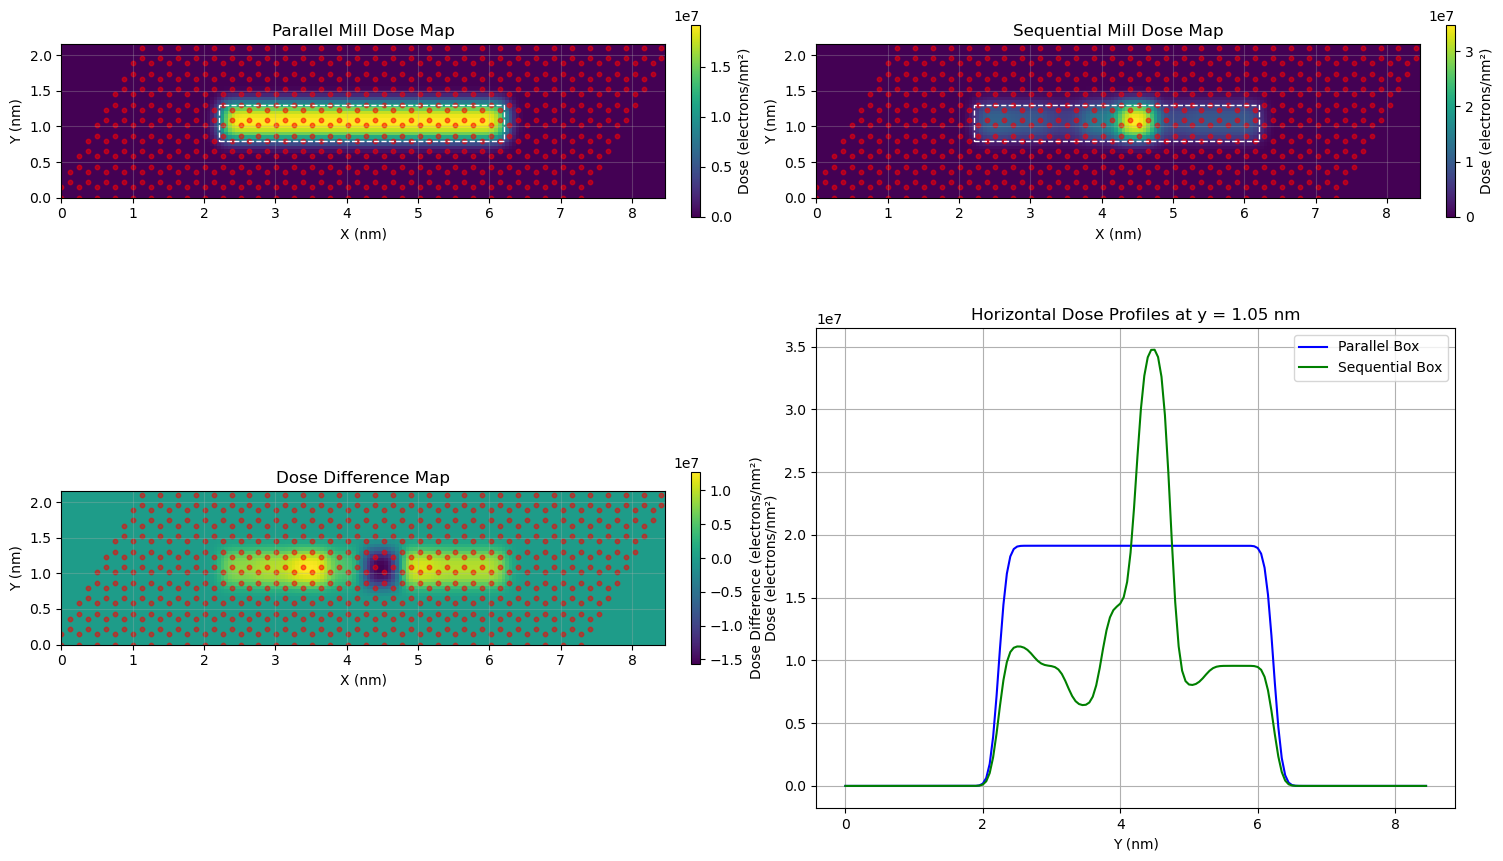

Total dose (Parallel): 2840934664.89 electrons/nm²
Total dose (Sequential): 1893958349.53 electrons/nm²
Dose difference sum (Parallel - Sequential): 5015730337.08 electrons/nm²


In [57]:
# Assume df_skinny and df_square exist from Steps 6 and 7
# Each has x, y, z, type, layer, neighbors, p_eject, dose, P_scaled, ejected
# Assume dose_skinny_total and dose_square_total from Step 6 and Step 7 outputs

# Milled region (from skinny box bounds in Step 6)
x_milled = x_bounds  # Use Step 6's x_bounds
y_milled = y_bounds  # Use Step 6's y_bounds

# Convolution grid setup
x_max_atoms = max(df_skinny['x'].max(), df_square['x'].max())
y_max_atoms = max(df_skinny['y'].max(), df_square['y'].max())
x_grid = np.arange(0, x_max_atoms + grid_step, grid_step)
y_grid = np.arange(0, y_max_atoms + grid_step, grid_step)
X, Y = np.meshgrid(x_grid, y_grid)

# Interpolate dose maps onto grid
interpolator_skinny = RegularGridInterpolator((y_grid, x_grid), dose_profile_skinny, method='linear', bounds_error=False, fill_value=0)
dose_skinny_grid = interpolator_skinny((Y, X)) * (data_cube_skinny.shape[0] - 1)  # Scale by steps
interpolator_square = RegularGridInterpolator((y_grid, x_grid), np.sum(dose_profile_square, axis=0), method='linear', bounds_error=False, fill_value=0)
dose_square_grid = interpolator_square((Y, X))

# Difference: Skinny - Square
dose_diff_grid = dose_skinny_grid - dose_square_grid

# Plot dose maps and bar plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Skinny box dose map
c0 = axes[0].imshow(dose_skinny_grid, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
plt.colorbar(c0, ax=axes[0], label='Dose (electrons/nm²)',fraction=0.015, pad=0.04)


axes[0].scatter(df_skinny['x'], df_skinny['y'], c='red', s=10, alpha=0.3)
rect = patches.Rectangle(
    (x_milled[0], y_milled[0]), x_milled[1] - x_milled[0], y_milled[1] - y_milled[0],
    linewidth=1, edgecolor='white', facecolor='none', linestyle='--'
)
axes[0].add_patch(rect)
axes[0].set_xlabel('X (nm)')
axes[0].set_ylabel('Y (nm)')
axes[0].set_title('Parallel Mill Dose Map')
axes[0].grid(True, alpha=0.3)

# Square box dose map
c1 = axes[1].imshow(dose_square_grid, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
plt.colorbar(c1, ax=axes[1], label='Dose (electrons/nm²)',fraction=0.015, pad=0.04)
axes[1].scatter(df_square['x'], df_square['y'], c='red', s=10, alpha=0.3)
rect = patches.Rectangle(
    (x_milled[0], y_milled[0]), x_milled[1] - x_milled[0], y_milled[1] - y_milled[0],
    linewidth=1, edgecolor='white', facecolor='none', linestyle='--'
)
axes[1].add_patch(rect)
axes[1].set_xlabel('X (nm)')
axes[1].set_ylabel('Y (nm)')
axes[1].set_title('Sequential Mill Dose Map')
axes[1].grid(True, alpha=0.3)

# Difference dose map
c2 = axes[2].imshow(dose_diff_grid, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], cmap='viridis')
plt.colorbar(c2, ax=axes[2], label='Dose Difference (electrons/nm²)',fraction=0.015, pad=0.04)
axes[2].scatter(df_skinny['x'], df_skinny['y'], c='red', s=10, alpha=0.3)
axes[2].set_xlabel('X (nm)')
axes[2].set_ylabel('Y (nm)')
axes[2].set_title('Dose Difference Map')
axes[2].grid(True, alpha=0.3)


# Line profiles
x_center = (x_milled[0] + x_milled[1]) / 2
x_idx = np.argmin(np.abs(x_grid - x_center))  # Nearest x_grid index

y_center = (y_milled[0] + y_milled[1]) / 2  # y-center of milled region

# Find nearest grid indices
y_idx = np.argmin(np.abs(y_grid - y_center))  # Nearest y_grid index for horizontal profile

# Horizontal profile (new)
skinny_profile = dose_skinny_grid[y_idx, :]  # Horizontal slice at y_center
square_profile = dose_square_grid[y_idx, :]

#skinny_profile = dose_skinny_grid[:, x_idx]  # Vertical slice
#square_profile = dose_square_grid[:, x_idx]  # Vertical slice
axes[3].plot(x_grid, skinny_profile, label='Parallel Box', color='blue')
axes[3].plot(x_grid, square_profile, label='Sequential Box', color='green')
axes[3].set_xlabel('Y (nm)')
axes[3].set_ylabel('Dose (electrons/nm²)')
axes[3].set_title(f'Horizontal Dose Profiles at y = {y_center:.2f} nm')
axes[3].grid(True)
axes[3].legend()

plt.savefig('figures/figure6_7/outputs/dose_comparison.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/dose_comparison.svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

# Print results
print(f"Total dose (Parallel): {dose_skinny_total:.2f} electrons/nm²")
print(f"Total dose (Sequential): {dose_square_total:.2f} electrons/nm²")
print(f"Dose difference sum (Parallel - Sequential): {dose_diff_grid.sum():.2f} electrons/nm²")

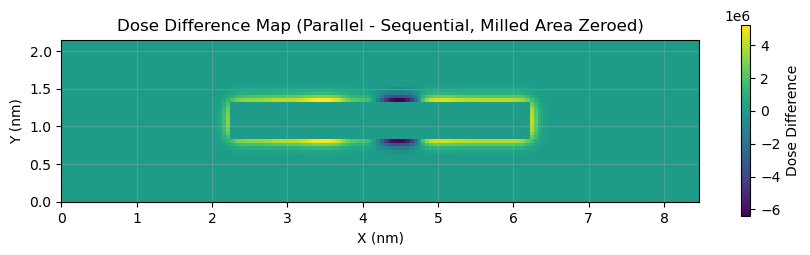

In [45]:
import matplotlib.pyplot as plt

# Since x_bounds_target = x_bounds and y_bounds_target = y_bounds in Step 7, they are the same
milled_area = (X >= x_bounds[0]) & (X <= x_bounds[1]) & (Y >= y_bounds[0]) & (Y <= y_bounds[1])

dose_difference = dose_diff_grid.copy()

# Set the dose difference to zero in the milled area
dose_difference[milled_area] = 0

# Create the figure and axis with a constrained layout
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
im = ax.imshow(dose_difference, origin='lower', extent=[0, x_max_atoms + grid_step, 0, y_max_atoms + grid_step], 
               cmap='viridis', interpolation='nearest')
ax.set_title('Dose Difference Map (Parallel - Sequential, Milled Area Zeroed)')
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Add a colorbar with adjusted size to match the plot height
cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.04)
cbar.set_label('Dose Difference')

plt.savefig('figures/figure6_7/outputs/dose_difference_map.png', bbox_inches='tight', dpi=200)
plt.savefig('figures/figure6_7/outputs/dose_difference_map.svg', bbox_inches='tight')
plt.show()